In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("driver_behavior_route_anomaly_dataset_with_derived_features.csv")

print(df.head())





   trip_id  driver_id  vehicle_id            timestamp   latitude   longitude  \
0        1        101        1001  2023-01-01 00:00:00  38.916143  -80.345269   
1        2        105        2002  2023-01-01 00:00:01  37.011830  -89.079516   
2        3        103        2002  2023-01-01 00:00:02  33.784009  -99.103643   
3        4        102        2002  2023-01-01 00:00:03  45.314835 -102.046210   
4        5        101        2002  2023-01-01 00:00:04  30.473386  -92.362577   

       speed  acceleration  steering_angle     heading  ...  \
0  39.484646      3.612832               6  212.555994  ...   
1   2.795422     -0.593295             -21  134.541146  ...   
2  13.842558     -0.209264              26  116.452839  ...   
3  69.121833     -0.413943               6   26.970247  ...   
4  13.061111      5.774122              -1  333.804023  ...   

   weather_conditions  road_type  traffic_condition  stop_events  \
0               Sunny      Urban              Light            0  

In [5]:

print("\nMissing Values")

print(df.isnull().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)


Missing Values
trip_id                         0
driver_id                       0
vehicle_id                      0
timestamp                       0
latitude                        0
longitude                       0
speed                           0
acceleration                    0
steering_angle                  0
heading                         0
trip_duration                   0
trip_distance                   0
fuel_consumption                0
rpm                             0
brake_usage                     0
lane_deviation                  0
weather_conditions              0
road_type                       0
traffic_condition               0
stop_events                     0
geofencing_violation            0
anomalous_event                 0
route_anomaly                   0
route_deviation_score           0
acceleration_variation          0
behavioral_consistency_index    0
dtype: int64


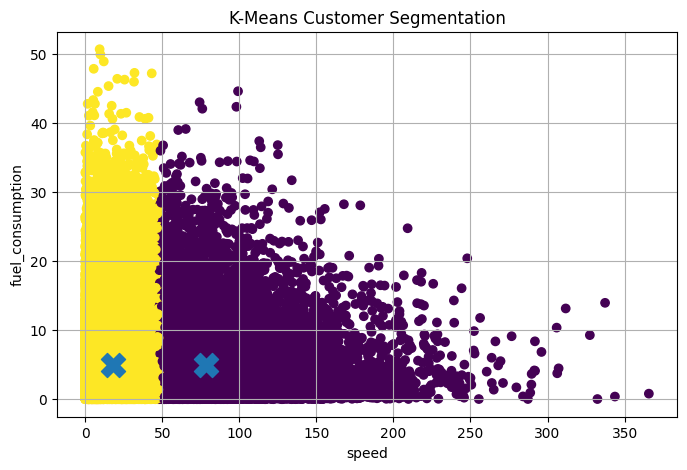

In [11]:
from sklearn import cluster

plt.figure(figsize=(8,5))

X = df[[
    "speed",
    "fuel_consumption",
]]

kmeans=KMeans(n_clusters=2,random_state=42)
clusters=kmeans.fit(X)
plt.scatter(
    X["speed"],
    X["fuel_consumption"],
    c=kmeans.labels_
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("speed")
plt.ylabel("fuel_consumption")
plt.title("K-Means Customer Segmentation")

plt.grid(True)

plt.show()